In [1]:
pip install pymc-bart

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import pymc as pm
import pymc_bart as pmb
from ISLP.bart import BART

C:\Users\Pytla\anaconda3\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
data = load_data("Carseats")
X = data.drop(columns=["Sales", "ShelveLoc"])
X[["Urban", "US"]] = X[["Urban", "US"]].replace({"Yes": 1, "No": 0})
X[["Urban", "US"]] = X[["Urban", "US"]].astype(int)

Y = np.where(data.Sales > 8,1,0)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=True)

C:\Users\Pytla\AppData\Local\Temp\ipykernel_23616\296936753.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[["Urban", "US"]] = X[["Urban", "US"]].replace({"Yes": 1, "No": 0})
C:\Users\Pytla\AppData\Local\Temp\ipykernel_23616\296936753.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  X[["Urban", "US"]] = X[["Urban", "US"]].replace({"Yes": 1, "No": 0})
C:\Users\Pytla\AppData\Local\Temp\ipykernel_23616\296936753.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old beh

In [4]:
regressor = DecisionTreeRegressor(random_state=0)
model_tree = regressor.fit(X_train, y_train)


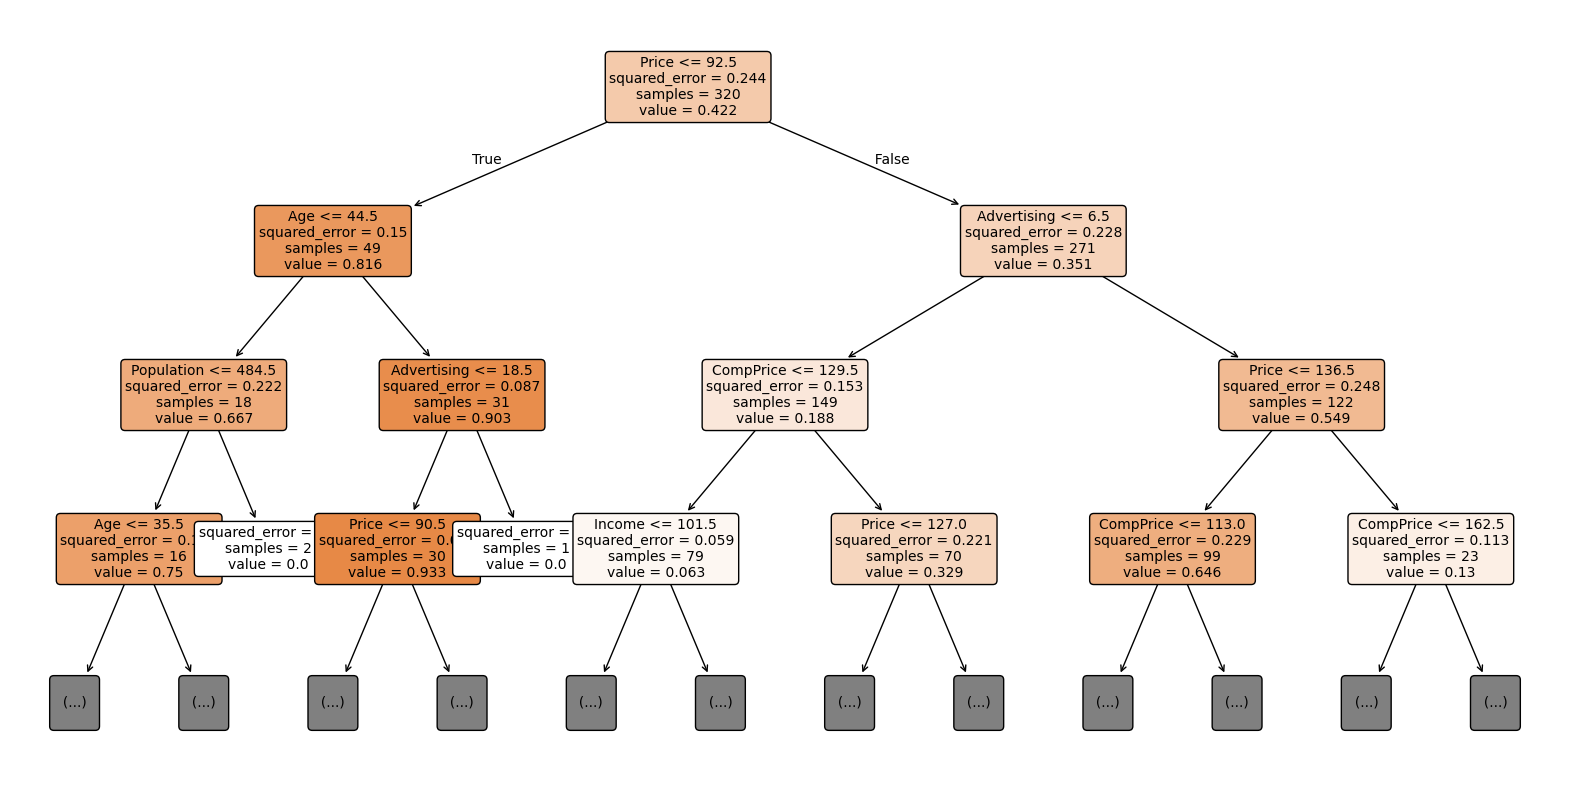

In [5]:
plt.figure(figsize=(20, 10))
plot_tree(
    model_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.show()

In [6]:
y_pred = model_tree.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)

print("Test MSE:", test_mse)

Test MSE: 0.325


### The MSE is quite significant assuming the fact that y_pred is binarized variable.

[np.float64(0.24508504019179025), np.float64(0.21556667101471008), np.float64(0.21497201634081828), np.float64(0.24443275119511582), np.float64(0.26730018715467674), np.float64(0.3133829778842811), np.float64(0.3065373148378067), np.float64(0.32351497448780775), np.float64(0.3231644210168243)]


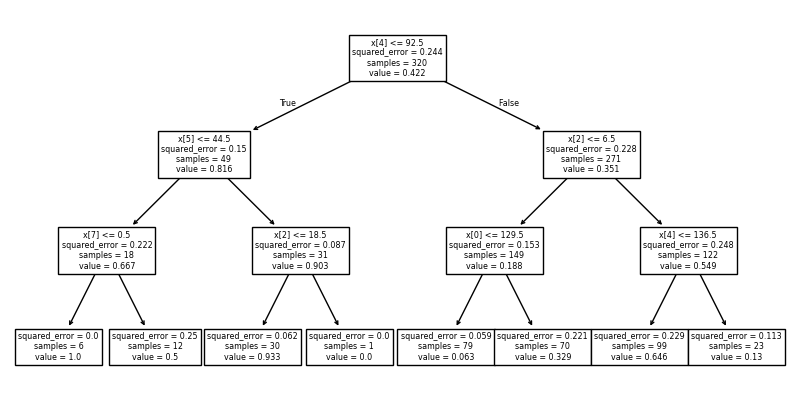

In [7]:
# c) optimal regression tree depth
depth = 10
cv_mse=[]

for d in range(1,depth):
    tree = DecisionTreeRegressor(random_state=42, max_depth=d)

    scores = cross_val_score(
        tree,
        X_train, 
        y_train,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    cv_mse.append(-scores.mean())
print(cv_mse)
    

cv_depths = {}
for i, val in enumerate(cv_mse):
    cv_depths[i] = val

best_depth = min(cv_depths, key=cv_depths.get) + 1

best_depth
# cv_depths

best_depth_tree_model = DecisionTreeRegressor(random_state=42, max_depth=best_depth)
model_best = best_depth_tree_model.fit(X_train, y_train)


plt.figure(figsize=(10, 5))
plot_tree(model_best)
plt.show()

In [8]:
bagging = RandomForestRegressor(
    n_estimators=100,   
    max_features=X_train.shape[1],
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)

print("Test MSE (Bagging):", test_mse)

Test MSE (Bagging): 0.224165


In [9]:
importances = bagging.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance


Price          0.294678
Advertising    0.171126
CompPrice      0.156547
Age            0.111277
Income         0.104371
Population     0.086887
Education      0.053565
Urban          0.017128
US             0.004422
dtype: float64

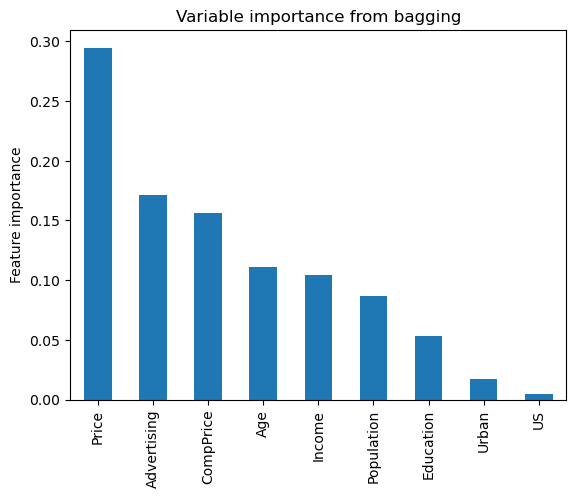

In [10]:
feature_importance.plot(kind='bar')
plt.ylabel("Feature importance")
plt.title("Variable importance from bagging")
plt.show()

Bagging is a technique that trains multiple models on various boostrap samples and then averaging their predictions.
This works because of the reduction of variance. Each tree is based on different sample works without sequence. In that term this is the opposite of Boosting which adjust 1 after another.

I performed Bagging using a random forest with all predictors at each split.
The test MSE was reduced compared to a single regression tree, indicating improved predictive performance.
This plot shows the Variable importance that the most influential predictors are those with the largest total decrease in MSE across the ensemble.

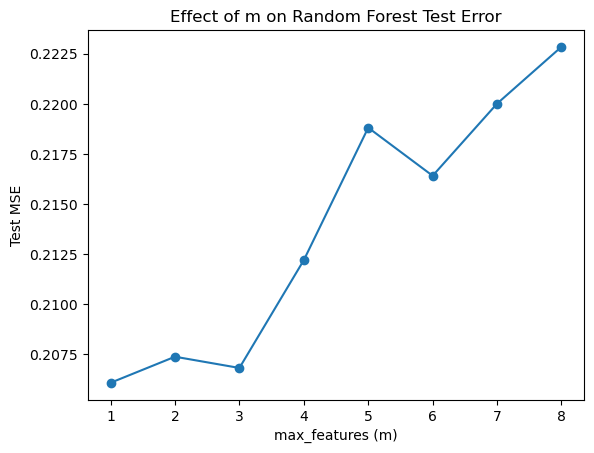

In [11]:
# e) 
m_values = range(1, X_train.shape[1])
mse_list = []

for m in m_values:
    rf = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    mse_list.append(mean_squared_error(y_test, y_pred))

plt.plot(m_values, mse_list, marker='o')
plt.xlabel("max_features (m)")
plt.ylabel("Test MSE")
plt.title("Effect of m on Random Forest Test Error")
plt.show()


Random forests build an ensemble of decision trees using bootstrapped samples and a random subset of predictors at each iteration.

# BART - Bayesian Additive Regression Tree

In [ ]:
bart_carseats = BART(random_state=0, burnin=100, ndraw=1000)
bart_carseats.fit(X_train, y_train)
bar_mse = np.mean((bart_carseats.predict(X_test) - y_test)**2)
bar_mse

In [ ]:
# not compiling